# Points and Quadtree Annotations

Builds two annotation files for H&E WSI image pairs:

1. **Quadtree tile index** → `quadtree_annotations.json`
2. **SuperPoint keypoint annotations** — runs SuperPoint on the HE image -> save detected keypoints in CNN-input and original tile pixel coordinates. Every tile has a number of keypoint prediction within `[KEYPOINT_MIN, KEYPOINT_MAX]`. → `he_keypoint_annotations_superpoint.json`

In [54]:
from pathlib import Path
import json
import sys

import tifffile
import numpy as np
from PIL import Image

sys.path.append(str(Path.cwd().parent))
sys.path.append(str(Path.cwd().parent / "pretraining_compare_detectors"))

import conf
from keypoint_detectors import SuperPointDetector


IMAGE_DIR = conf.IMAGE_DIR
LABELS_PATH = conf.LABELS_PATH
ANNOTATION_PATH = conf.ANNOTATION_PATH
HE_KEYPOINT_ANNOTATION_PATH = conf.HE_KEYPOINT_ANNOTATION_PATH

WSI_PAGES = conf.WSI_PAGES
CNN_INPUT_HEIGHT = conf.CNN_INPUT_HEIGHT
CNN_INPUT_WIDTH = conf.CNN_INPUT_WIDTH
MAX_CROP_DEPTH = conf.MAX_CROP_DEPTH

print(f"System   : {conf.SYSTEM_PREFIX}")
print(f"Labels   : {LABELS_PATH}")
print(f"Output   : {ANNOTATION_PATH}")
print(f"KP Output: {HE_KEYPOINT_ANNOTATION_PATH}")

System   : macos
Labels   : /Users/alexanderhallmann/Desktop/medical-image-registration/setup/macos_labels.json
Output   : /Users/alexanderhallmann/Desktop/medical-image-registration/data/macos_quadtree_annotations.json
KP Output: /Users/alexanderhallmann/Desktop/medical-image-registration/data/macos_he_keypoint_annotations_superpoint.json


## Part 1 — Quadtree Tile Index

Reads image pair labels, selects the coarsest pyramid page that still covers the CNN input dimensions at each quadtree depth, and writes one entry per `(pair, depth, x, y)` tile to `quadtree_annotations.json`.

In [55]:
def matrix_dict_to_list(m):
    return [
        [m["t_00"], m["t_01"], m["t_02"]],
        [m["t_10"], m["t_11"], m["t_12"]],
        [m["t_20"], m["t_21"], m["t_22"]],
    ]


def load_pairs_from_labels(labels_path, image_dir):
    with open(labels_path, "r", encoding="utf-8") as f:
        labels = json.load(f)

    pairs = []

    for pair_id, item in enumerate(labels):
        source_id = item["source_image_id"]
        target_id = item["target_image_id"]

        source_path = image_dir / f"{source_id}.data"
        target_path = image_dir / f"{target_id}.data"

        if not source_path.exists():
            raise FileNotFoundError(source_path)

        if not target_path.exists():
            raise FileNotFoundError(target_path)

        pairs.append({
            "pair_id": pair_id,

            # source/moving gets registered to target/fixed
            "moving_path": str(source_path),
            "fixed_path": str(target_path),

            "source_image_id": source_id,
            "target_image_id": target_id,

            "registration_error": item["registration_error"],
            "transformation_matrix": matrix_dict_to_list(item["transformation_matrix"]),
        })

    return pairs

In [56]:
def choose_pair_pyramid_page(fixed_path, moving_path, crop_depth, input_height=CNN_INPUT_HEIGHT, input_width=CNN_INPUT_WIDTH):
    grid = 2 ** crop_depth

    with tifffile.TiffFile(fixed_path) as fixed_slide, tifffile.TiffFile(moving_path) as moving_slide:
        candidates = []

        for page_idx in WSI_PAGES:
            fixed_h, fixed_w = fixed_slide.pages[page_idx].shape[:2]
            moving_h, moving_w = moving_slide.pages[page_idx].shape[:2]

            fixed_tile_h = fixed_h // grid
            fixed_tile_w = fixed_w // grid

            moving_tile_h = moving_h // grid
            moving_tile_w = moving_w // grid

            min_tile_h = min(fixed_tile_h, moving_tile_h)
            min_tile_w = min(fixed_tile_w, moving_tile_w)

            if min_tile_h >= input_height and min_tile_w >= input_width:
                candidates.append((page_idx, min_tile_h, min_tile_w))

    if not candidates:
        return None

    return candidates[-1]

In [57]:
def build_quadtree_index(pairs, max_crop_depth, input_height=CNN_INPUT_HEIGHT, input_width=CNN_INPUT_WIDTH):
    tile_jobs = []

    for pair in pairs:
        for crop_depth in range(max_crop_depth + 1):
            chosen = choose_pair_pyramid_page(
                fixed_path=pair["fixed_path"],
                moving_path=pair["moving_path"],
                crop_depth=crop_depth,
                input_height=input_height,
                input_width=input_width,
            )

            if chosen is None:
                continue

            pyramid_page_idx, tile_h, tile_w = chosen
            grid = 2 ** crop_depth

            for y_idx in range(grid):
                for x_idx in range(grid):
                    tile_jobs.append({
                        "pair_id": pair["pair_id"],

                        "fixed_path": pair["fixed_path"],
                        "moving_path": pair["moving_path"],

                        "source_image_id": pair["source_image_id"],
                        "target_image_id": pair["target_image_id"],

                        "crop_depth": crop_depth,
                        "grid": grid,
                        "x_idx": x_idx,
                        "y_idx": y_idx,

                        "pyramid_page_idx": pyramid_page_idx,
                        "tile_h": tile_h,
                        "tile_w": tile_w,
                        "cnn_input_height": input_height,
                        "cnn_input_width": input_width,

                        "registration_error": pair["registration_error"],
                        "transformation_matrix": pair["transformation_matrix"],
                    })

    return tile_jobs


def save_json(data, path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2)

In [ ]:
pairs = load_pairs_from_labels(LABELS_PATH, IMAGE_DIR)

tile_jobs = build_quadtree_index(
    pairs=pairs,
    max_crop_depth=MAX_CROP_DEPTH,
    input_height=CNN_INPUT_HEIGHT,
    input_width=CNN_INPUT_WIDTH,
)

save_json(tile_jobs, ANNOTATION_PATH)

print(f"pairs: {len(pairs)}")
print(f"tile jobs: {len(tile_jobs)}")
print(f"saved to: {ANNOTATION_PATH}")

print("\nFirst job:")
print(tile_jobs[0])

print("\nLast job:")
print(tile_jobs[-1])wha

pairs: 8
tile jobs: 10920
saved to: /Users/alexanderhallmann/Desktop/medical-image-registration/data/macos_quadtree_annotations.json

First job:
{'pair_id': 0, 'fixed_path': '/Users/alexanderhallmann/Desktop/medical-image-registration/data/images/6045.data', 'moving_path': '/Users/alexanderhallmann/Desktop/medical-image-registration/data/images/6036.data', 'source_image_id': 6036, 'target_image_id': 6045, 'crop_depth': 0, 'grid': 1, 'x_idx': 0, 'y_idx': 0, 'pyramid_page_idx': 4, 'tile_h': 1388, 'tile_w': 2054, 'cnn_input_height': 344, 'cnn_input_width': 512, 'registration_error': 104.38675487149722, 'transformation_matrix': [[0.999398059318965, -0.00020282846028934223, -1243.5138093608236], [0.00024455038200216076, 0.9999230769021725, -32.762125098451975], [0.0, 0.0, 1.0]]}

Last job:
{'pair_id': 7, 'fixed_path': '/Users/alexanderhallmann/Desktop/medical-image-registration/data/images/6051.data', 'moving_path': '/Users/alexanderhallmann/Desktop/medical-image-registration/data/images/60

In [59]:
TILE_LIMIT = 200  # set to None to process all tiles

LOG_EVERY = 100
KEYPOINT_MIN = 20
KEYPOINT_MAX = 60
KEYPOINT_TARGET = (KEYPOINT_MIN + KEYPOINT_MAX) // 2  # 40
MAX_CORRECTION_PASSES = 20

INITIAL_CONF_THRESH = 0.385

SUPERPOINT_WEIGHTS = Path.cwd().parent / "external" / "superpoint_v1.pth"
detector = SuperPointDetector(
    weights_path=str(SUPERPOINT_WEIGHTS),
    nms_dist=8,
    conf_thresh=INITIAL_CONF_THRESH,
    nn_thresh=0.7,
)

## Part 2 — SuperPoint Keypoint Annotations

Detects keypoints on the fixed image of every tile using SuperPoint at `INITIAL_CONF_THRESH`. Each entry in the output file extends its quadtree counterpart with `fixed_keypoints_cnn`, `fixed_keypoints_tile`, `fixed_keypoint_count`, `conf_thresh`, `converged`, and the full `thresh_history` / `count_history` for the correction loop.

Set `TILE_LIMIT` to an integer to process only the first N tiles during development, or `None` for a full run.

In [60]:
def _job_key(job):
    return (job["pair_id"], job["crop_depth"], job["x_idx"], job["y_idx"])


def is_in_range(count):
    return KEYPOINT_MIN <= count <= KEYPOINT_MAX


def next_conf_thresh(thresh_history, count_history):
    lo_thresh = 0.05
    hi_thresh = 0.95

    for t, c in zip(thresh_history, count_history):
        if c > KEYPOINT_MAX:
            lo_thresh = max(lo_thresh, t)
        elif c < KEYPOINT_MIN:
            hi_thresh = min(hi_thresh, t)

    if lo_thresh < hi_thresh:
        return (lo_thresh * hi_thresh) ** 0.5

    last_thresh = thresh_history[-1]
    last_count = count_history[-1]
    if last_count == 0:
        return max(0.05, last_thresh * 0.5)
    return min(0.95, max(0.05, last_thresh * last_count / KEYPOINT_TARGET))


def load_existing_annotations(path):
    if not path.exists():
        return [], set()
    with open(path, "r", encoding="utf-8") as f:
        existing = json.load(f)
    return existing, {_job_key(j) for j in existing}


def load_fixed_page(path, pyramid_page_idx, page_cache):
    key = (str(path), int(pyramid_page_idx))
    if key not in page_cache:
        with tifffile.TiffFile(path) as slide:
            page_cache[key] = slide.pages[pyramid_page_idx].asarray()
    return page_cache[key]


def crop_fixed_tile(page, x_idx, y_idx, grid):
    H, W = page.shape[:2]
    tile_w = W // grid
    tile_h = H // grid
    x0 = x_idx * tile_w
    y0 = y_idx * tile_h
    x1 = W if x_idx == grid - 1 else x0 + tile_w
    y1 = H if y_idx == grid - 1 else y0 + tile_h
    return page[y0:y1, x0:x1], x1 - x0, y1 - y0


def tile_to_gray(crop, input_height, input_width):
    img = Image.fromarray(crop.astype(np.uint8) if crop.dtype != np.uint8 else crop).convert("L")
    img = img.resize((input_width, input_height), resample=Image.BILINEAR)
    return np.array(img, dtype=np.float32) / 255.0


def detect_keypoints(gray, actual_tile_w, actual_tile_h, input_w, input_h, detector):
    pts = detector.detect(gray)

    if pts.ndim != 2 or pts.shape[1] == 0:
        return [], [], 0

    scale_x = actual_tile_w / input_w
    scale_y = actual_tile_h / input_h

    pts_cnn = [[float(p[0]), float(p[1]), float(p[2])] for p in pts.T]
    pts_tile = [[p[0] * scale_x, p[1] * scale_y, p[2]] for p in pts_cnn]

    return pts_cnn, pts_tile, len(pts_cnn)


def _make_annotated_entry(job, pts_cnn, pts_tile, n, conf_thresh, correction_passes, thresh_history, count_history):
    return {
        "pair_id": job["pair_id"],
        "fixed_path": job["fixed_path"],
        "moving_path": job["moving_path"],
        "source_image_id": job["source_image_id"],
        "target_image_id": job["target_image_id"],
        "crop_depth": job["crop_depth"],
        "grid": job["grid"],
        "x_idx": job["x_idx"],
        "y_idx": job["y_idx"],
        "pyramid_page_idx": job["pyramid_page_idx"],
        "tile_h": job["tile_h"],
        "tile_w": job["tile_w"],
        "cnn_input_height": job["cnn_input_height"],
        "cnn_input_width": job["cnn_input_width"],
        "fixed_keypoint_count": n,
        "conf_thresh": conf_thresh,
        "correction_passes": correction_passes,
        "converged": is_in_range(n),
        "thresh_history": thresh_history,
        "count_history": count_history,
        "registration_error": job["registration_error"],
        "transformation_matrix": job["transformation_matrix"],
        "fixed_keypoints_cnn": pts_cnn,
        "fixed_keypoints_tile": pts_tile,
    }


def build_keypoint_annotations(tile_jobs, detector, conf_thresh, results, done_keys, log_every):
    page_cache = {}
    remaining = [job for job in tile_jobs if _job_key(job) not in done_keys]

    for i, job in enumerate(remaining):
        page = load_fixed_page(job["fixed_path"], job["pyramid_page_idx"], page_cache)
        crop, actual_tile_w, actual_tile_h = crop_fixed_tile(page, job["x_idx"], job["y_idx"], job["grid"])

        gray = tile_to_gray(crop, job["cnn_input_height"], job["cnn_input_width"])
        pts_cnn, pts_tile, n = detect_keypoints(
            gray, actual_tile_w, actual_tile_h,
            job["cnn_input_width"], job["cnn_input_height"], detector,
        )

        results.append(_make_annotated_entry(
            job, pts_cnn, pts_tile, n, conf_thresh,
            correction_passes=0,
            thresh_history=[conf_thresh],
            count_history=[n],
        ))

        if (i + 1) % log_every == 0:
            print(f"  {i + 1}/{len(remaining)}")


def run_correction_pass(results, detector, log_every):
    to_correct = [
        (i, job) for i, job in enumerate(results)
        if not job.get("converged", False) and job.get("correction_passes", 0) < MAX_CORRECTION_PASSES
    ]

    page_cache = {}

    for processed, (result_idx, job) in enumerate(to_correct):
        new_thresh = next_conf_thresh(job["thresh_history"], job["count_history"])
        detector.superpoint.conf_thresh = new_thresh

        page = load_fixed_page(job["fixed_path"], job["pyramid_page_idx"], page_cache)
        crop, actual_tile_w, actual_tile_h = crop_fixed_tile(page, job["x_idx"], job["y_idx"], job["grid"])

        gray = tile_to_gray(crop, job["cnn_input_height"], job["cnn_input_width"])
        pts_cnn, pts_tile, n = detect_keypoints(
            gray, actual_tile_w, actual_tile_h,
            job["cnn_input_width"], job["cnn_input_height"], detector,
        )

        results[result_idx] = _make_annotated_entry(
            job, pts_cnn, pts_tile, n,
            conf_thresh=new_thresh,
            correction_passes=job["correction_passes"] + 1,
            thresh_history=job["thresh_history"] + [new_thresh],
            count_history=job["count_history"] + [n],
        )

        if (processed + 1) % log_every == 0:
            print(f"  {processed + 1}/{len(to_correct)}")

In [61]:
active_tile_jobs = tile_jobs[:TILE_LIMIT] if TILE_LIMIT is not None else tile_jobs

existing, done_keys = load_existing_annotations(HE_KEYPOINT_ANNOTATION_PATH)
annotated_jobs = list(existing)

print(f"Tile limit : {TILE_LIMIT if TILE_LIMIT is not None else 'all'} / {len(tile_jobs)}")
if done_keys:
    print(f"Resuming   : {len(done_keys)}/{len(active_tile_jobs)} already done")

interrupted = False
try:
    build_keypoint_annotations(active_tile_jobs, detector, INITIAL_CONF_THRESH, annotated_jobs, done_keys, log_every=LOG_EVERY)
except KeyboardInterrupt:
    interrupted = True
    print(f"\nInterrupted at {len(annotated_jobs)}/{len(active_tile_jobs)}")
finally:
    save_json(annotated_jobs, HE_KEYPOINT_ANNOTATION_PATH)

total_kp = sum(j["fixed_keypoint_count"] for j in annotated_jobs)
avg_kp = total_kp / len(annotated_jobs) if annotated_jobs else 0

status = f"interrupted at {len(annotated_jobs)}/{len(active_tile_jobs)}" if interrupted else "complete"
print(f"status    : {status}")
print(f"saved to  : {HE_KEYPOINT_ANNOTATION_PATH}")
print(f"tile jobs : {len(annotated_jobs)}")
print(f"total kp  : {total_kp}")
print(f"avg kp    : {avg_kp:.1f}")

  100/10920
  200/10920
  300/10920
  400/10920
  500/10920
  600/10920
  700/10920
  800/10920
  900/10920
  1000/10920
  1100/10920
  1200/10920
  1300/10920
  1400/10920
  1500/10920
  1600/10920
  1700/10920
  1800/10920
  1900/10920
  2000/10920
  2100/10920
  2200/10920

Interrupted at 2277/10920
status    : interrupted at 2277/10920
saved to  : /Users/alexanderhallmann/Desktop/medical-image-registration/data/macos_he_keypoint_annotations_superpoint.json
tile jobs : 2277
total kp  : 194035
avg kp    : 85.2


In [ ]:
with open(HE_KEYPOINT_ANNOTATION_PATH, "r", encoding="utf-8") as f:
    jobs = json.load(f)

rebuilt = []
patched = 0
for job in jobs:
    n = job.get("fixed_keypoint_count", len(job.get("fixed_keypoints_cnn", [])))
    conf = job.get("conf_thresh", INITIAL_CONF_THRESH)
    passes = job.get("correction_passes", 0)
    thresh_history = job.get("thresh_history", [conf])
    count_history = job.get("count_history", [n])

    if "thresh_history" not in job or "count_history" not in job:
        patched += 1

    rebuilt.append(_make_annotated_entry(
        job,
        pts_cnn=job.get("fixed_keypoints_cnn", []),
        pts_tile=job.get("fixed_keypoints_tile", []),
        n=n,
        conf_thresh=conf,
        correction_passes=passes,
        thresh_history=thresh_history,
        count_history=count_history,
    ))

save_json(rebuilt, HE_KEYPOINT_ANNOTATION_PATH)
print(f"patched/reordered {patched}/{len(rebuilt)} entries")

patched/reordered 0/671 entries


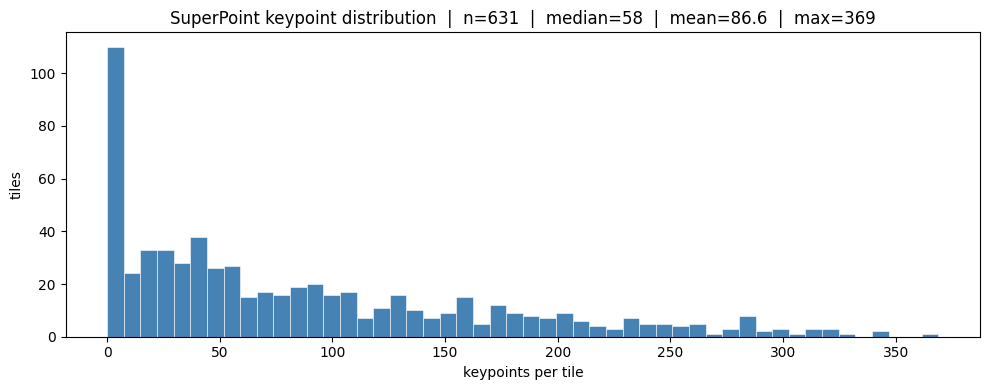

In [ ]:
import matplotlib.pyplot as plt

with open(HE_KEYPOINT_ANNOTATION_PATH, "r", encoding="utf-8") as f:
    jobs = json.load(f)

counts = [j["fixed_keypoint_count"] for j in jobs]
mean = sum(counts) / len(counts)
std = (sum((c - mean) ** 2 for c in counts) / len(counts)) ** 0.5
median = sorted(counts)[len(counts) // 2]

print(f"n      : {len(counts)}")
print(f"min    : {min(counts)}")
print(f"max    : {max(counts)}")
print(f"median : {median}")
print(f"mean   : {mean:.1f}")
print(f"std    : {std:.1f}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(counts, bins=50, color="steelblue", edgecolor="white", linewidth=0.4)
ax.set_xlabel("keypoints per tile")
ax.set_ylabel("tiles")
ax.set_title(
    f"SuperPoint keypoint distribution  |  "
    f"n={len(counts)}  |  median={median}  |  "
    f"mean={mean:.1f}  |  std={std:.1f}  |  max={max(counts)}"
)
plt.tight_layout()
plt.show()

In [ ]:
with open(HE_KEYPOINT_ANNOTATION_PATH, "r", encoding="utf-8") as f:
    annotated_jobs = json.load(f)

passes_run = 0
interrupted = False

try:
    while True:
        remaining = [
            j for j in annotated_jobs
            if not j.get("converged", False) and j.get("correction_passes", 0) < MAX_CORRECTION_PASSES
        ]
        if not remaining:
            break

        print(f"Pass {passes_run + 1}: {len(remaining)} tiles to correct")
        run_correction_pass(annotated_jobs, detector, log_every=LOG_EVERY)
        passes_run += 1

        converged_now = sum(1 for j in annotated_jobs if j.get("converged", False))
        print(f"  converged: {converged_now}/{len(annotated_jobs)}")

except KeyboardInterrupt:
    interrupted = True
    print(f"\nInterrupted after {passes_run} passes")
finally:
    save_json(annotated_jobs, HE_KEYPOINT_ANNOTATION_PATH)

converged = sum(1 for j in annotated_jobs if j.get("converged", False))
status = "interrupted" if interrupted else "complete"
print(f"status        : {status}")
print(f"passes run    : {passes_run}")
print(f"converged     : {converged}/{len(annotated_jobs)}")
print(f"not converged : {len(annotated_jobs) - converged} (kept, marked converged=false)")
print(f"saved to      : {HE_KEYPOINT_ANNOTATION_PATH}")

## Threshold Correction Loop

Re-runs SuperPoint on every non-converged tile with a per-tile adjusted `conf_thresh`, targeting `KEYPOINT_TARGET` keypoints. Loops until all tiles have converged or exhausted `MAX_CORRECTION_PASSES`. Saves on interrupt and resumes cleanly on re-run.